Python function that will generate simulated raw data for the generalized matching equation (GME) based on specified bias and sensitivity parameters. Each dataset corresponds to a different reinforcer ratio condition, with 100 sessions per condition.

The matching equation in log form is:

log(*B*1/*B*2)=*a*⋅log(*R*1/*R*2)+log(*b*)

Where:
*B*1, *B*2: behavior counts (e.g., number of choices)
*R*1, *R*2: reinforcer counts
a: sensitivity to reinforcement ratio
b: bias toward one alternative

In [7]:
def simulate_gme_data(sensitivity=1.0, bias=1.0, n_sessions=100, seed=42, behavior_sd=0.25):
    """
    Simulates noisy session-level data based on the Generalized Matching Equation.

    Parameters:
    - sensitivity (float): a, the sensitivity parameter
    - bias (float): b, the bias parameter (B1/B2 when R1 = R2)
    - n_sessions (int): number of sessions per condition
    - seed (int): random seed for reproducibility
    - behavior_sd (float): standard deviation to inject noise in log(B1/B2)

    Returns:
    - pd.DataFrame: Simulated data
    """
    np.random.seed(seed)
    ratios = [(1, 9), (1, 3), (1, 1), (3, 1), (9, 1)]
    all_data = []

    for condition_id, (r1_sched, r2_sched) in enumerate(ratios, start=1):
        true_log_r_ratio = np.log(r1_sched / r2_sched)
        true_log_b_ratio = sensitivity * true_log_r_ratio + np.log(bias)

        for session in range(1, n_sessions + 1):
            # Add noise to the behavior ratio (log-space)
            noisy_log_b_ratio = np.random.normal(loc=true_log_b_ratio, scale=behavior_sd)
            b_ratio = np.exp(noisy_log_b_ratio)

            total_choices = np.random.randint(400, 1000)
            min_responses = 10
            max_tries = 20
            total_choices = np.random.randint(400, 1000)

            b1_prob = b_ratio / (1 + b_ratio)

            for _ in range(max_tries):
                b1 = np.random.binomial(total_choices, b1_prob)
                b2 = total_choices - b1
                if b1 >= min_responses and b2 >= min_responses:
                    break
            else:
                # Fallback: clip to ensure minimum counts
                b1 = max(min_responses, int(total_choices * b1_prob))
                b2 = total_choices - b1
                if b2 < min_responses:
                    b2 = min_responses + np.random.randint(-5, 5)
                    b1 = total_choices - b2


            # Add Poisson noise to reinforcement contact
            r1_contacts = np.random.poisson(lam=r1_sched * b1 / (b1 + b2 + 1e-5))
            r2_contacts = np.random.poisson(lam=r2_sched * b2 / (b1 + b2 + 1e-5))

            # Avoid zeros
            r1_contacts = max(1, r1_contacts)
            r2_contacts = max(1, r2_contacts)

            all_data.append({
                "condition": condition_id,
                "session": session,
                "b1": b1,
                "b2": b2,
                "r1": r1_contacts,
                "r2": r2_contacts,
                "schedule_r1": r1_sched,
                "schedule_r2": r2_sched,
            })

    return pd.DataFrame(all_data)

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_gme_seaborn_condition_means(df, title="Generalized Matching Plot (Condition Means)"):
    """
    Plots mean log(B1/B2) vs mean log(R1/R2) for each condition, with regression fit.
    """
    # Compute log ratios at session level
    df = df.copy()
    df['log_b_ratio'] = np.log((df['b1'] + 1e-5) / (df['b2'] + 1e-5))
    df['log_r_ratio'] = np.log((df['r1'] + 1e-5) / (df['r2'] + 1e-5))

    # Group by condition and average
    grouped = df.groupby('condition')[['log_r_ratio', 'log_b_ratio']].mean().reset_index()

    # Plot only the means
    plt.figure(figsize=(8, 6))
    plt.scatter(grouped['log_r_ratio'], grouped['log_b_ratio'], color='blue', s=80, label='Condition Mean')

    # Fit regression to means
    slope, intercept = np.polyfit(grouped['log_r_ratio'], grouped['log_b_ratio'], 1)
    x_vals = np.linspace(grouped['log_r_ratio'].min(), grouped['log_r_ratio'].max(), 100)
    y_vals = slope * x_vals + intercept
    plt.plot(x_vals, y_vals, 'k--', label=f'Fit: slope={slope:.2f}, bias={np.exp(intercept):.2f}')
    plt.plot(x_vals, x_vals, 'gray', linestyle=':', label='Perfect Matching')
    plt.xlabel("Mean log(R1 / R2) per condition")
    plt.ylabel("Mean log(B1 / B2) per condition")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

    print(f"Estimated sensitivity (slope): {slope:.3f}")
    print(f"Estimated bias (antilog of intercept): {np.exp(intercept):.3f}")

/var/folders/c5/vpx80swj4yb9ytlnrk8w2qnr0000gn/T/ipykernel_68925/3341557308.py:23: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


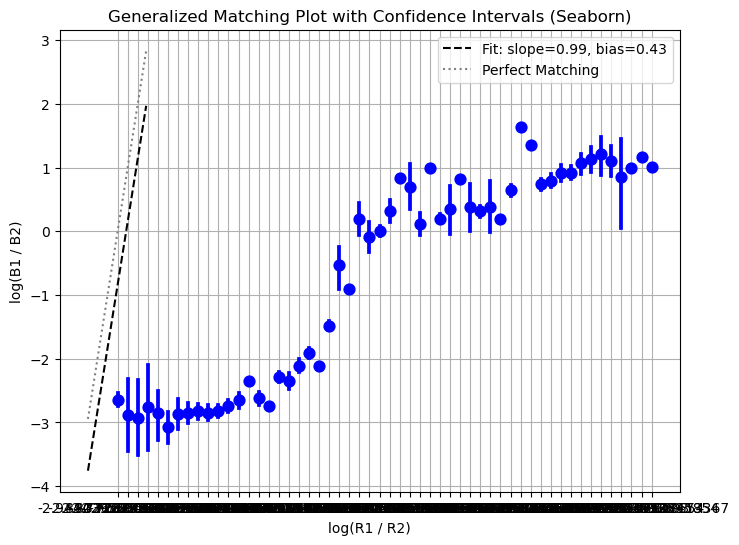

Estimated sensitivity (slope): 0.991
Estimated bias (antilog of intercept): 0.432


In [30]:
df = simulate_gme_data(sensitivity=0.79, bias=.35, n_sessions=1000, seed=42, behavior_sd=0.58)
pid = 'P09'
df['PID'] = pid
df.to_csv(f"./Lab Data/gme_data_{pid}.csv", index=False)
plot_gme_seaborn(df)

In [ ]:
temp_df = df[df['condition']==1]
temp_df['b_ratio'] = temp_df['b1'] / (temp_df['b1'] + temp_df['b2'])
temp_df['r_ratio'] = temp_df['r1'] / (temp_df['r1'] + temp_df['r2'])
temp_df

/tmp/ipython-input-51-1746654131.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df['b_ratio'] = temp_df['b1'] / (temp_df['b1'] + temp_df['b2'])
/tmp/ipython-input-51-1746654131.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df['r_ratio'] = temp_df['r1'] / (temp_df['r1'] + temp_df['r2'])


,condition,session,b1,b2,r1,r2,schedule_r1,schedule_r2,b_ratio,r_ratio
0,1,1,453,18,0,0,1,9,0.961783,NaN
1,1,2,44,814,1,6,1,9,0.051282,0.142857
2,1,3,10,579,0,9,1,9,0.016978,0.000000
3,1,4,688,167,3,3,1,9,0.804678,0.500000
4,1,5,10,733,0,6,1,9,0.013459,0.000000
...,...,...,...,...,...,...,...,...,...,...
995,1,996,10,393,0,13,1,9,0.024814,0.000000
996,1,997,18,411,0,9,1,9,0.041958,0.000000
997,1,998,10,845,0,8,1,9,0.011696,0.000000
998,1,999,10,396,0,14,1,9,0.024631,0.000000
